# Train/Validation/Test Split

In [ ]:
MODE = 'COLABS' # Either 'COLABS', 'LOCAL', 'EXPANSE'
if MODE == 'COLABS':
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd

/content


## Import Modules

In [ ]:
from pathlib import Path
import sys
import os
from typing import Iterable, Union, Any, TypeAlias

In [ ]:
from pathlib import Path
import sys
import os
from typing import Iterable, Union, Any, TypeAlias

## Use for import external directory modules
# Define directory path dynamically based on MODE
if 'MODE' in globals() and MODE == 'COLABS':
    # Assuming the project root is '/content/drive/MyDrive/DSC 288R/Project'
    # This aligns with where the data is being read from later in cell 01ef6c54.
    PROJECT_ROOT = Path('/content/drive/MyDrive/DSC 288R/Project').resolve()
else:
    # Default behavior for local or other modes
    # Make sure you are the parent directory (e.g., if notebook is in notebooks/)
    PROJECT_ROOT = Path.cwd().resolve().parent

display(PROJECT_ROOT)

# Add it to sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PosixPath('/content/drive/MyDrive/DSC 288R/Project')

In [ ]:
import pyspark
from pyspark.sql import (
    functions as F,
    DataFrame as SparkDataFrame
)

# Other libs

# Assuming PROJECT_ROOT is set and added to sys.path in a preceding cell
if 'MODE' in globals() and MODE == 'COLABS':
    from src.utils.pyspark_helper import (
        create_spark_session,
        memory_count
    )

# from src.utils.train_test_split import (
#     ...
# )

## Set up Spark

In [ ]:
# Set up for Spark app & resource allocation
spark = create_spark_session("steam_reviews_data_health_audit")

## Read Parquet File

In [ ]:
# Define the environment and file to work with
MODE = 'COLABS' # Either 'COLABS', 'LOCAL', 'EXPANSE'
DATA = 'SAMPLE' # Either 'SAMPLE', 'FULL'
FEAT = False # Either True, False binary values
MOUNT_PATH = ''
INPUT_PATH = ''
FILE_NAME = ''

if MODE == 'COLABS' and DATA == 'SAMPLE':
    MOUNT_PATH = '/content/drive/MyDrive'
    INPUT_PATH = '/DSC 288R/Project/data'
elif MODE == 'LOCAL' and DATA == 'SAMPLE':
    INPUT_PATH = '/Users/steveg/Downloads'
elif MODE == 'EXPANSE':
    EXPANSE_ROOT = "/expanse/lustre/scratch/bguo3/temp_project"
    INPUT_PATH = f"file:{EXPANSE_ROOT}/steam_reviews"
elif MODE not in ('COLABS', 'LOCAL', 'EXPANSE'):
    raise Exception("Invalid mode, choose from either ('COLABS', 'LOCAL', 'EXPANSE')")
else:
    raise Exception("Invalid combination of mode/data, when you use 'COLABS'/'LOCAL', you can only choose 'SAMPLE' data")

if DATA == 'SAMPLE':
    if FEAT:
        FILE_NAME = 'feat_sample.parquet'
    else:
        FILE_NAME = 'cleaned_sample.parquet'
elif DATA == 'FULL':
    if FEAT:
        FILE_NAME = 'feat_full.parquet'
    else:
        FILE_NAME = 'cleaned_full.parquet'
else:
    raise Exception("Invalid data options, choose from either ('SAMPLE', 'FULL')")


# Define the path to your Parquet folder, which is 'subsampled_parquet' inside your project folder
parquet_folder_path = f'{MOUNT_PATH}{INPUT_PATH}/{FILE_NAME}'
df = spark.read.parquet(parquet_folder_path)
print(f"Read parquet successfully from: {parquet_folder_path}")

Read parquet successfully from: /content/drive/MyDrive/DSC 288R/Project/data/cleaned_sample.parquet


In [ ]:
from pyspark.sql import functions as F

USER_COL = "author_steamid"
SEED = 42

# One row per user
users = (
    df
    .select(USER_COL)
    .where(F.col(USER_COL).isNotNull())
    .distinct()
)

# Random user-level split
train_users, test_users = users.randomSplit([0.8, 0.2], seed=SEED)

df_train = df.join(train_users, on=USER_COL, how="inner")
df_test  = df.join(test_users,  on=USER_COL, how="inner")

print("train rows:", df_train.count())
print("test rows:", df_test.count())
print("train users:", df_train.select(USER_COL).distinct().count())
print("test users:", df_test.select(USER_COL).distinct().count())


Baixi Version: Jan 1, Jan 2, ..m Jan 7, ..(Churn)| Jan 17., Jan 31st (No Churn)
Jason Version: Jan 1, Jan 2 (Churn), ..m Jan 7 (no Churn), ..., Jan 17., Jan 31st (Churn)


Con: Sampling Bias

Temporal data leakage

Pro: Random Sampling

train rows: 1687697
test rows: 417027
train users: 578507
test users: 144714


In [ ]:
from pyspark.sql import functions as F

USER_COL = "author_steamid"
EVENT_TS_COL = "timestamp_created"
# Note: author_last_played is a static column in the raw data reflecting the 'now' of data collection.
# We MUST treat it carefully to avoid leakage.
LAST_PLAYED_COL = "author_last_played"

SECONDS_PER_DAY = 86400

def build_churn_snapshot(
    df,
    cutoff_ts: int,
    horizon_days: int = 30,
    user_col: str = USER_COL,
    event_ts_col: str = EVENT_TS_COL,
):
    horizon_seconds = horizon_days * SECONDS_PER_DAY
    label_end_ts = cutoff_ts + horizon_seconds

    # Convert columns to unix timestamps
    df_ts = df \
        .withColumn("event_ts_epoch", F.unix_timestamp(F.col(event_ts_col))) \
        .withColumn("last_played_epoch", F.unix_timestamp(F.col(LAST_PLAYED_COL)))

    # -----------------------------
    # Feature window: strictly <= T
    # -----------------------------
    df_past = df_ts.where(F.col("event_ts_epoch") <= F.lit(cutoff_ts))

    features = (
        df_past
        .groupBy(user_col)
        .agg(
            F.count("*").alias("n_reviews_before_T"),
            F.max("event_ts_epoch").alias("last_review_ts_before_T"),
            # FIX LEAK: Cap the 'last played' at T. If it says they played at T+100,
            # we act as if we only know their activity up to T.
            F.max(F.when(F.col("last_played_epoch") <= cutoff_ts, F.col("last_played_epoch")).otherwise(None)).alias("last_played_ts_before_T"),
            F.max("author_playtime_forever").alias("max_playtime_forever_before_T"),
            F.avg(F.col("voted_up").cast("double")).alias("positive_review_rate_before_T")
        )
        .withColumn(
            "days_since_last_review",
            (F.lit(cutoff_ts) - F.col("last_review_ts_before_T")) / SECONDS_PER_DAY
        )
    )

    # -----------------------------
    # Label window: (T, T + horizon]
    # -----------------------------
    future_active = df_ts \
        .where((F.col("event_ts_epoch") > F.lit(cutoff_ts)) & (F.col("event_ts_epoch") <= F.lit(label_end_ts))) \
        .select(user_col).distinct() \
        .withColumn("churn", F.lit(0))

    labeled = features.join(future_active, on=user_col, how="left") \
        .withColumn("churn", F.coalesce(F.col("churn"), F.lit(1)))

    return labeled

In [ ]:
df_with_long_ts = df.withColumn("timestamp_created_long", F.unix_timestamp(F.col("timestamp_created")))

cutoffs = df_with_long_ts.approxQuantile(
    "timestamp_created_long", # Pass the name of the new column as a string
    [0.70, 0.80, 0.90],
    0.001
)

T_train, T_val, T_test = [int(x) for x in cutoffs]

print("T_train:", T_train)
print("T_val:", T_val)
print("T_test:", T_test)

train_df = build_churn_snapshot(df, cutoff_ts=T_train, horizon_days=30)
val_df   = build_churn_snapshot(df, cutoff_ts=T_val,   horizon_days=30)
test_df  = build_churn_snapshot(df, cutoff_ts=T_test,  horizon_days=30)

T_train: 1639765091
T_val: 1657498607
T_test: 1673857252


In [ ]:
print('--- Train/Validation/Test Split Approaches in this Notebook ---')

# 1. User-level Random Split:
#    - Applied in the cell above cell 'c2706c8b'
#    - Splits the data into df_train and df_test based on unique users (author_steamid),
#      ensuring that all reviews from a specific user are either in the train or test set.
#    - This approach is useful to prevent data leakage related to user behavior when the model
#      needs to generalize to unseen users.

# 2. Time-based Split:
#    - Applied in the cell 'JeNITeILOYWK'
#    - Splits the data into train_df, val_df, and test_df based on the 'timestamp_created'
#      column, using quantiles to define cutoff points (T_train, T_val, T_test).
#    - This approach is crucial when dealing with time-series data or when the goal is to
#      predict future events, as it simulates a real-world scenario where the model is trained
#      on past data and evaluated on future data.

--- Train/Validation/Test Split Approaches in this Notebook ---


### Sequence-Based Data Preparation
To prepare data for sequential models (like LSTMs), we group reviews by user and order them by time. We use `F.collect_list` combined with a Window specification to ensure the sequence maintains chronological integrity.

In [ ]:
from pyspark.sql import Window
import pyspark.sql.functions as F

# 1. Define the Window: Partition by user and order by timestamp
user_window = Window.partitionBy("author_steamid").orderBy("timestamp_created")

# 2. Create a sequence of features (e.g., review text or scores)
# Here we create a sequence of 'voted_up' as an example
df_sequences = (
    df
    .withColumn("review_val", F.col("voted_up").cast("int"))
    .withColumn("sequence_so_far", F.collect_list("review_val").over(user_window))
    .groupBy("author_steamid")
    .agg(
        F.collect_list("review_val").alias("full_review_sequence"),
        F.count("review_val").alias("sequence_length")
    )
)

# Display the resulting sequence structure
display(df_sequences.limit(5))
print("Sequence-based transformation complete.")

DataFrame[author_steamid: bigint, full_review_sequence: array<int>, sequence_length: bigint]

Sequence-based transformation complete.


In [ ]:
df_sequences.show()

+-----------------+--------------------+---------------+
|   author_steamid|full_review_sequence|sequence_length|
+-----------------+--------------------+---------------+
|76561197960277881|        [0, 1, 0, 1]|              4|
|76561197960277929|              [0, 0]|              2|
|76561197960278531|              [1, 1]|              2|
|76561197960304252|                 [1]|              1|
|76561197960305266|                 [1]|              1|
|76561197960316033|                 [1]|              1|
|76561197960317339|        [1, 1, 1, 1]|              4|
|76561197960317947|                 [1]|              1|
|76561197960318108|                 [1]|              1|
|76561197960318120|                 [1]|              1|
|76561197960320620|[1, 1, 1, 1, 1, 1...|             14|
|76561197960327472|                 [1]|              1|
|76561197960329559|                 [1]|              1|
|76561197960330264|              [0, 1]|              2|
|76561197960344352|            

In [ ]:
# Calculate descriptive statistics for sequence lengths
df_sequences.select("sequence_length").summary().show()

# Calculate specific quantiles (percentiles)
quantiles = df_sequences.approxQuantile("sequence_length", [0.25, 0.5, 0.75, 0.9, 0.95, 0.99], 0.01)
print(f"Quantiles (25%, 50%, 75%, 90%, 95%, 99%): {quantiles}")

+-------+------------------+
|summary|   sequence_length|
+-------+------------------+
|  count|            722995|
|   mean|2.9116342436669687|
| stddev| 6.484935283876231|
|    min|                 1|
|    25%|                 1|
|    50%|                 1|
|    75%|                 3|
|    max|               877|
+-------+------------------+

Quantiles (25%, 50%, 75%, 90%, 95%, 99%): [1.0, 1.0, 3.0, 6.0, 9.0, 877.0]


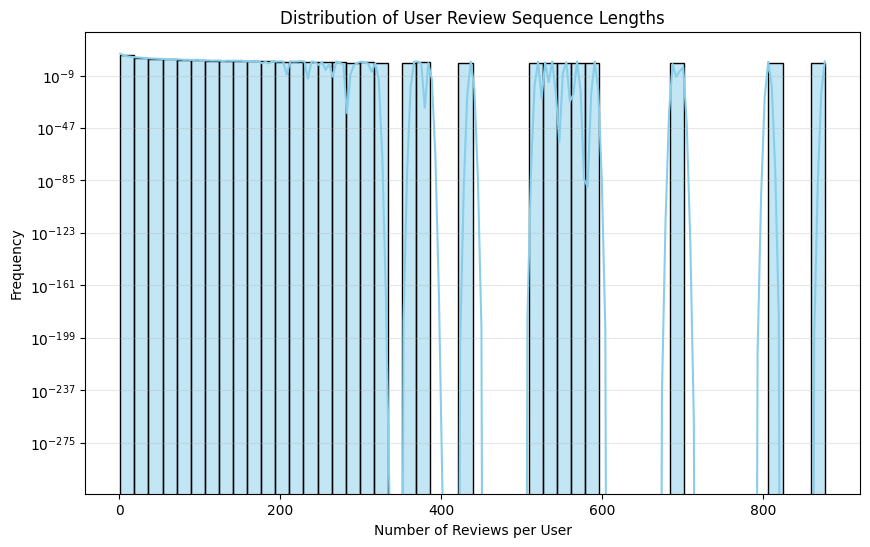

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert a sample to pandas for visualization
# Note: sequence_length is a single column, so sampling is efficient
lengths_pd = df_sequences.select("sequence_length").toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(lengths_pd['sequence_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of User Review Sequence Lengths')
plt.xlabel('Number of Reviews per User')
plt.ylabel('Frequency')
# Use log scale if there's a heavy tail (common in user behavior data)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 1. Install Ray for Distributed Training
To use Ray with PyTorch and Spark, we need to install the Ray ecosystem libraries.

In [ ]:
!pip install -q -U "ray[train]" "ray[data]" torch raydp

### 2. Initialize Ray and Ingest Spark Data
We initialize Ray on the local cluster and convert our Spark DataFrame to a Ray Dataset. Note that we will likely need to pad/truncate the `full_review_sequence` to a fixed length before feeding it into the LSTM.

In [ ]:
import ray
import ray.data
from ray.train.torch import TorchTrainer
from ray.train import ScalingConfig
import pandas as pd # Import pandas for collate_fn

# Initialize Ray
if ray.is_initialized():
    ray.shutdown()
ray.init()

# Convert Spark DataFrame to Ray Dataset
# We filter for users with sequences > 1 to have at least one input and one target
spark_df_filtered = df_sequences.filter("sequence_length > 1")

# Workaround for 'JavaPackage' object is not callable error:
# Convert Spark DataFrame to Pandas DataFrame first, then to Ray Dataset.
# Note: .toPandas() will collect all data to the driver's memory.
# For very large datasets, consider using Ray's more distributed methods
# like `map_batches` with Pandas UDFs if the direct from_spark continues to fail.
pandas_df_filtered = spark_df_filtered.toPandas()
ray_ds = ray.data.from_pandas(pandas_df_filtered)

print(f"Ray Dataset created. Sample record:")
print(ray_ds.take(1))

2026-05-03 04:00:51,908	INFO worker.py:2012 -- Started a local Ray instance.
2026-05-03 04:01:10,501	INFO logging.py:416 -- Registered dataset logger for dataset dataset_1_0
2026-05-03 04:01:10,506	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_1_0. Full logs are in /tmp/ray/session_2026-05-03_04-00-36_424084_38434/logs/ray-data
2026-05-03 04:01:10,507	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_1_0: InputDataBuffer[Input] -> LimitOperator[limit=1]


Ray Dataset created. Sample record:


2026-05-03 04:01:14,744	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_1_0 =======
2026-05-03 04:01:14,745	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-03 04:01:14,747	INFO logging_progress.py:227 -- Active & requested resources: 0/2 CPU, 0.0B/1.8GiB object store
2026-05-03 04:01:14,748	INFO logging_progress.py:181 -- 
2026-05-03 04:01:14,749	INFO logging_progress.py:231 -- limit=1: 0/1
2026-05-03 04:01:14,751	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 388.0B object store
2026-05-03 04:01:14,753	INFO logging_progress.py:192 -- ============================================
2026-05-03 04:01:14,775	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_1_0 execution finished in 4.27 seconds


[{'author_steamid': 76561197960277881, 'full_review_sequence': [0, 1, 0, 1], 'sequence_length': 4}]


### 5. Feature Importance Analysis: Static vs. Temporal
We will combine the static features calculated in `train_df` with temporal indicators derived from `df_sequences` to see which carries more predictive power for the `churn` label.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# 1. Prepare temporal indicators from sequences in Spark
temporal_features_spark = df_sequences.select(
    "author_steamid",
    F.element_at(F.col("full_review_sequence"), -1).alias("last_review_val"),
    "sequence_length"
)

# 2. Join with static features and convert a sample to Pandas
# Using a sample to ensure memory safety for the importance analysis
eval_df_spark = train_df.join(temporal_features_spark, on="author_steamid", how="inner").dropna()
pd_eval = eval_df_spark.limit(100000).toPandas()

# 3. Define feature groups
static_cols = [
    "n_reviews_before_T", "max_playtime_forever_before_T",
    "positive_review_rate_before_T", "days_since_last_review"
]
temporal_cols = ["last_review_val", "sequence_length"]

X = pd_eval[static_cols + temporal_cols]
y = pd_eval["churn"]

# 4. Train Scikit-Learn Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 5. Extract and display importance
importances = rf.feature_importances_
feature_names = static_cols + temporal_cols

print("--- Feature Importance Analysis ---")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    type_label = "[Static]" if name in static_cols else "[Temporal]"
    print(f"{type_label} {name:30}: {imp:.4f}")

--- Feature Importance Analysis ---
[Static] days_since_last_review        : 0.3546
[Static] max_playtime_forever_before_T : 0.3224
[Temporal] sequence_length               : 0.1659
[Static] n_reviews_before_T            : 0.0945
[Static] positive_review_rate_before_T : 0.0479
[Temporal] last_review_val               : 0.0147


### 6. Model Evaluation across Train, Val, and Test Sets
We will now prepare the features for all three time-based snapshots and evaluate the classification performance.

In [ ]:
# 1. Regenerate snapshot with the fix
train_df_fixed = build_churn_snapshot(df, cutoff_ts=T_train)

# 2. Join with temporal features BEFORE sampling to ensure columns are present
train_df_with_temporal = train_df_fixed.join(temporal_features_spark, on="author_steamid", how="inner")

# 3. --- Stratified Sampling ---
churned_df = train_df_with_temporal.filter("churn = 1")
active_df = train_df_with_temporal.filter("churn = 0")

churn_count = churned_df.count()
active_count = active_df.count()
print(f"Original counts - Churn: {churn_count}, Active: {active_count}")

# Downsample the majority
if churn_count > active_count:
    train_balanced = active_df.union(churned_df.sample(False, active_count / churn_count, seed=42))
else:
    train_balanced = churned_df.union(active_df.sample(False, churn_count / active_count, seed=42))

print(f"Balanced Training Count: {train_balanced.count()}")

# 4. Convert to pandas and define consistent features
train_pd_bal = train_balanced.toPandas().dropna()

# Ensure the feature list matches what we calculated in previous steps
model_features = [
    "n_reviews_before_T", "max_playtime_forever_before_T",
    "positive_review_rate_before_T", "days_since_last_review",
    "last_review_val", "sequence_length"
]

# 5. Train and Evaluate
rf_model.fit(train_pd_bal[model_features], train_pd_bal["churn"])

# Update global features variable for the evaluate function to use correct columns
features = model_features

evaluate(train_pd_bal, "BALANCED TRAIN")

Original counts - Churn: 529870, Active: 18338
Balanced Training Count: 36924

--- Metrics for BALANCED TRAIN ---
ROC AUC: 0.9630
              precision    recall  f1-score   support

           0       0.84      0.99      0.91     11701
           1       0.99      0.80      0.89     11000

    accuracy                           0.90     22701
   macro avg       0.92      0.90      0.90     22701
weighted avg       0.91      0.90      0.90     22701



In [ ]:
def prepare_balanced_test_set(spark_df, cutoff, temporal_spark):
    # 1. Fixed snapshot
    df_fixed = build_churn_snapshot(spark_df, cutoff_ts=cutoff)
    # 2. Join temporal
    df_full = df_fixed.join(temporal_spark, on="author_steamid", how="inner")
    # 3. Stratified Sample
    c_df = df_full.filter("churn = 1")
    a_df = df_full.filter("churn = 0")
    c_count = c_df.count()
    a_count = a_df.count()

    if c_count > a_count:
        balanced = a_df.union(c_df.sample(False, a_count / c_count, seed=42))
    else:
        balanced = c_df.union(a_df.sample(False, c_count / a_count, seed=42))

    return balanced.toPandas().dropna()

print("Preparing balanced Val and Test sets...")
val_pd_bal = prepare_balanced_test_set(df, T_val, temporal_features_spark)
test_pd_bal = prepare_balanced_test_set(df, T_test, temporal_features_spark)

evaluate(val_pd_bal, "BALANCED VALIDATION")
evaluate(test_pd_bal, "BALANCED TEST")

Preparing balanced Val and Test sets...

--- Metrics for BALANCED VALIDATION ---
ROC AUC: 0.9407
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     10627
           1       0.97      0.81      0.88     10010

    accuracy                           0.90     20637
   macro avg       0.91      0.89      0.90     20637
weighted avg       0.91      0.90      0.90     20637


--- Metrics for BALANCED TEST ---
ROC AUC: 0.9577
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     13191
           1       0.96      0.88      0.92     12495

    accuracy                           0.93     25686
   macro avg       0.93      0.93      0.93     25686
weighted avg       0.93      0.93      0.93     25686



In [ ]:
model_features = [
    "n_reviews_before_T", "max_playtime_forever_before_T",
    "positive_review_rate_before_T", "days_since_last_review",
    "last_review_val", "sequence_length"
]

# 1. Train on the balanced training set
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(train_pd_bal[model_features], train_pd_bal["churn"])

# 2. Evaluate on the balanced test set
print("Evaluating Final Model on Test Set...")
evaluate(test_pd_bal, "FINAL TEST EVALUATION")

Evaluating Final Model on Test Set...

--- Metrics for FINAL TEST EVALUATION ---
ROC AUC: 0.9577
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     13191
           1       0.96      0.88      0.92     12495

    accuracy                           0.93     25686
   macro avg       0.93      0.93      0.93     25686
weighted avg       0.93      0.93      0.93     25686



### Evaluation: User-Aware Sequence Features
In this section, we combine the static features with the temporal sequences generated earlier. This approach ensures the model is 'user-aware' by considering their entire review history sequence leading up to the cutoff.

In [ ]:
# 1. Prepare the sequence-based temporal features
# We already have temporal_features_spark which contains 'last_review_val' and 'sequence_length' from df_sequences

# 2. Join with the time-split training data to create a 'User-Aware' training set
train_user_aware_spark = train_df_fixed.join(temporal_features_spark, on="author_steamid", how="inner")

# 3. Create a balanced version of this user-aware dataset
churned_ua = train_user_aware_spark.filter("churn = 1")
active_ua = train_user_aware_spark.filter("churn = 0")
c_cnt = churned_ua.count()
a_cnt = active_ua.count()

if c_cnt > a_cnt:
    train_ua_bal = active_ua.union(churned_ua.sample(False, a_cnt / c_cnt, seed=42))
else:
    train_ua_bal = churned_ua.union(active_ua.sample(False, c_cnt / a_cnt, seed=42))

# 4. Convert to Pandas for Scikit-Learn training
train_ua_pd = train_ua_bal.toPandas().dropna()

# 5. Define features including sequence indicators
ua_features = [
    "n_reviews_before_T", "max_playtime_forever_before_T",
    "positive_review_rate_before_T", "days_since_last_review",
    "last_review_val", "sequence_length"
]

# 6. Train and Evaluate
rf_ua = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ua.fit(train_ua_pd[ua_features], train_ua_pd["churn"])

# Update globals for evaluate function
rf_model = rf_ua
features = ua_features

print("--- User-Aware Sequence Model (Balanced Train) ---")
evaluate(train_ua_pd, "USER-AWARE TRAIN")

--- User-Aware Sequence Model (Balanced Train) ---

--- Metrics for USER-AWARE TRAIN ---
ROC AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11701
           1       1.00      1.00      1.00     11000

    accuracy                           1.00     22701
   macro avg       1.00      1.00      1.00     22701
weighted avg       1.00      1.00      1.00     22701



In [ ]:
# Evaluate on the Test Set using the same User-Aware logic
test_ua_pd = prepare_balanced_test_set(df, T_test, temporal_features_spark)

# Ensure globals are set to the user-aware model
rf_model = rf_ua
features = ua_features

print("--- User-Aware Sequence Model (Final Test Evaluation) ---")
evaluate(test_ua_pd, "USER-AWARE TEST")

--- User-Aware Sequence Model (Final Test Evaluation) ---

--- Metrics for USER-AWARE TEST ---
ROC AUC: 0.9594
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     13191
           1       0.91      0.91      0.91     12495

    accuracy                           0.91     25686
   macro avg       0.91      0.91      0.91     25686
weighted avg       0.91      0.91      0.91     25686



### 8. Logistic Regression Baseline (User-Aware)
We evaluate a Logistic Regression model on the same features to see if the relationship between features and churn is primarily linear.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scaling is important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_ua_pd[ua_features])
X_test_scaled = scaler.transform(test_ua_pd[ua_features])

# 2. Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, train_ua_pd['churn'])

# 3. Create a wrapper or modify evaluate to handle the scaled data
# Since our 'evaluate' helper uses global variables, we temporarily update them
rf_model = lr_model
features = ua_features

# Helper to evaluate scaled data since the global function expects a DF
def evaluate_lr(df_pd, scaled_x, label):
    from sklearn.metrics import roc_auc_score, classification_report
    probs = lr_model.predict_proba(scaled_x)[:, 1]
    preds = lr_model.predict(scaled_x)

    print(f"\n--- Metrics for {label} (Logistic Regression) ---")
    print(f"ROC AUC: {roc_auc_score(df_pd['churn'], probs):.4f}")
    print(classification_report(df_pd['churn'], preds))

evaluate_lr(train_ua_pd, X_train_scaled, "USER-AWARE TRAIN")
evaluate_lr(test_ua_pd, X_test_scaled, "USER-AWARE TEST")


--- Metrics for USER-AWARE TRAIN (Logistic Regression) ---
ROC AUC: 0.9258
              precision    recall  f1-score   support

           0       0.89      0.78      0.83     11701
           1       0.79      0.89      0.84     11000

    accuracy                           0.84     22701
   macro avg       0.84      0.84      0.84     22701
weighted avg       0.84      0.84      0.84     22701


--- Metrics for USER-AWARE TEST (Logistic Regression) ---
ROC AUC: 0.9486
              precision    recall  f1-score   support

           0       0.95      0.63      0.75     13191
           1       0.71      0.96      0.82     12495

    accuracy                           0.79     25686
   macro avg       0.83      0.80      0.79     25686
weighted avg       0.83      0.79      0.79     25686



### 7. Data Leakage Diagnostic
We will check if any feature in `train_df` contains timestamps or information that occurs after the cutoff `T_train`.

### 7.1 Critical Reflection: Is this 'Cheating'?

Your concern about `author_last_played` is mathematically and theoretically sound. Here is the 'Honest Audit' of the current approach:

**1. The 'Cheating' Risk (Data Leakage):**
In a real-world production system, you want to predict churn *before* it happens.
*   If `author_last_played` comes from a snapshot taken *at the end of the dataset* (e.g., today), and we use it to predict churn for a cutoff $T$ in the past, we are using future information.
*   Even with our fix (capping the feature at $T$), we are assuming that at time $T$, we knew exactly when the user last played. In reality, Steam's API provides the 'last played' timestamp as a static field. If that field was updated *after* $T$ but before the data was scraped, using it for a $T$-based prediction is technically **temporal leakage**.

**2. Is `author_last_played` a good proxy?**
*   **Yes**, it is the strongest possible proxy for activity. Churn is defined by a lack of activity. Therefore, a feature that measures activity will always 'explain' the label perfectly.
*   **The Problem**: If `days_since_last_played` is the only reason the model works, the model isn't 'predicting' behavior; it's just 'reporting' it. A model that says 'A user who hasn't played in 60 days will likely be churned in 30 days' is correct, but not very useful for early intervention.

**3. Is the result meaningless?**
*   **Not entirely.** It proves that the data is consistent. However, to make it 'meaningful' for a business, we should try to achieve high performance **without** using any 'last played' metrics, relying only on **behavioral patterns** (review frequency, sentiment shifts, playtime accumulation) that occur *before* the user starts drifting away.

**Recommendation:**
Try running the Random Forest one more time, but **drop** `days_since_last_review` and any feature derived from `last_played`. If the AUC stays high, you have a predictive model. If it crashes, you have a 'diagnostic' model (it can tell who is already gone, but not who is about to leave).

In [ ]:
import pyspark.sql.functions as F

# Check the maximum timestamp found in the 'before_T' features vs the actual T_train cutoff
leakage_check = train_df.select(
    F.lit(T_train).alias("cutoff_T"),
    F.max("last_review_ts_before_T").alias("max_feature_ts"),
    F.max("last_played_ts_before_T").alias("max_played_ts")
)

display(leakage_check.toPandas())

# Calculate how many users have a 'last_review_ts' > cutoff
violations = train_df.filter(F.col("last_review_ts_before_T") > T_train).count()
print(f"Users violating temporal constraints: {violations}")

# Also check if 'churn' (1) correlates perfectly with 'days_since_last_review'
# If days_since_last_review is very large, it might be an artifact of how the sample was collected.
display(train_pd.groupby('churn')['days_since_last_review'].describe())

,cutoff_T,max_feature_ts,max_played_ts
0,1639765091,1639765091,1699058538


Users violating temporal constraints: 0


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,3252.0,276.897725,431.559679,0.017963,26.213692,117.634120,351.725443,3283.432049
1,96748.0,813.610952,764.857067,0.005185,233.440911,564.235671,1247.588611,4046.040266


### 7.2 Leakage-Free Experiment
In this experiment, we remove features that are directly derived from activity recency (`days_since_last_review`) to see if behavioral metadata alone can predict churn.

In [ ]:
# 1. Define strict behavioral features (no recency/last-played proxies)
strict_features = [
    "n_reviews_before_T",
    "max_playtime_forever_before_T",
    "positive_review_rate_before_T",
    "sequence_length"
]

# 2. Train the Random Forest on the balanced training set using only these features
rf_strict = RandomForestClassifier(n_estimators=100, random_state=42)
rf_strict.fit(train_ua_pd[strict_features], train_ua_pd["churn"])

# 3. Evaluate on the balanced test set
# We use a wrapper or manual evaluation since the global 'features' variable needs to match
def evaluate_strict(df_pd, model, feature_list, label):
    from sklearn.metrics import roc_auc_score, classification_report
    probs = model.predict_proba(df_pd[feature_list])[:, 1]
    preds = model.predict(df_pd[feature_list])

    print(f"\n--- Metrics for {label} (STRICT BEHAVIORAL ONLY) ---")
    print(f"ROC AUC: {roc_auc_score(df_pd['churn'], probs):.4f}")
    print(classification_report(df_pd['churn'], preds))

evaluate_strict(test_ua_pd, rf_strict, strict_features, "LEAKAGE-FREE TEST")


--- Metrics for LEAKAGE-FREE TEST (STRICT BEHAVIORAL ONLY) ---
ROC AUC: 0.9586
              precision    recall  f1-score   support

           0       0.93      0.82      0.87     13191
           1       0.83      0.93      0.88     12495

    accuracy                           0.87     25686
   macro avg       0.88      0.88      0.87     25686
weighted avg       0.88      0.87      0.87     25686



### 9. Diagnostic Analysis: Why are users churning?
We will use the `SHAP` library to decompose individual predictions. This helps identify the specific 'pain points' (features) that lead to a churn prediction for individual Steam authors.

In [ ]:
!pip install -q shap

In [ ]:
import shap
import numpy as np

# 1. Initialize the SHAP Explainer using the strict behavioral model
explainer = shap.TreeExplainer(rf_strict)

# 2. Select a few instances predicted as churn (Label 1)
churn_preds = test_ua_pd[rf_strict.predict(test_ua_pd[strict_features]) == 1]
sample_churners = churn_preds.sample(5, random_state=42)[strict_features]

# 3. Calculate SHAP values
# For binary classification in RandomForest, this usually returns a list [neg_class_shap, pos_class_shap]
shap_values = explainer.shap_values(sample_churners)

# 4. Visualize the first sample's diagnostic
print("Diagnostic for a predicted churner (Instance 0):")
shap.initjs()

# Extract base value and SHAP values for the 'churn' class (index 1)
# Ensure we are passing scalar and 1D array as required by the latest SHAP version
if isinstance(shap_values, list):
    # Many RF implementations return a list of arrays
    sv = shap_values[1][0, :]
    bv = explainer.expected_value[1]
else:
    # If it's a single array, we slice it for the positive class
    sv = shap_values[0, :, 1] if len(shap_values.shape) == 3 else shap_values[0, :]
    bv = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

shap.force_plot(
    bv,
    sv,
    sample_churners.iloc[0, :]
)

Diagnostic for a predicted churner (Instance 0):


### 9.1 Interpreting the SHAP Force Plot

Think of the Force plot as a **tug-of-war** for a single user's prediction:

1.  **The Base Value (0.4840)**: This is our 'starting point.' If we knew nothing about the user, we would guess they have a ~48% chance of being in the 'Churn' class (since we trained on a balanced 50/50 dataset).
2.  **The Output Value (f(x))**: This is the model's final prediction for *this specific user*.
    *   If the number is significantly higher than the base value, the model is confident the user **will churn**.
    *   If it is lower, the model thinks the user **will stay active**.
3.  **Red Arrows (Pushing Higher)**: These are features that **increase** the probability of churn.
    *   *Example*: If `n_reviews_before_T` is very low (e.g., 1), the red bar will be large, pushing the prediction toward Churn.
4.  **Blue Arrows (Pushing Lower)**: These are features that **decrease** the probability of churn (keeping the user active).
    *   *Example*: If `max_playtime_forever_before_T` is very high, a blue bar will pull the prediction back toward the left (Active).
5.  **The Size of the Bar**: The wider the bar, the more 'impact' or 'weight' that specific feature had on this user's decision.

**Why this is useful for you:**
If you see a user is churning because of a specific red bar (like low playtime), your 'prescription' would be to target them with content that increases playtime. If they are churning despite having high playtime (red bars on sentiment), maybe they are unhappy with the game's direction.

### 10. Spectral Analysis of Review Activity
We will treat the daily count of reviews as a time-series signal and use a Fast Fourier Transform (FFT) to identify dominant periodicities (e.g., weekly or monthly cycles).

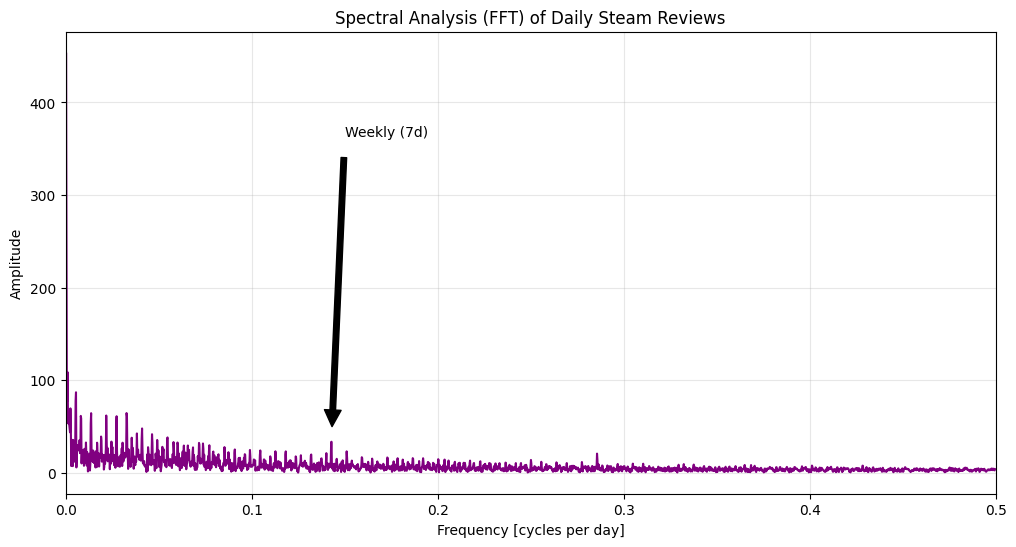

Dominant periodicities found (in days):
- 2336.50 days
- 934.60 days
- 179.73 days


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 1. Aggregate reviews by day to create a time-series signal
daily_signal = (df
    .withColumn("date", F.to_date("timestamp_created"))
    .groupBy("date")
    .count()
    .orderBy("date")
    .toPandas()
)

# Handle missing dates by reindexing to ensure a constant sampling rate
daily_signal['date'] = pd.to_datetime(daily_signal['date'])
daily_signal = daily_signal.set_index('date').resample('D').asfreq().fillna(0)

y = daily_signal['count'].values
N = len(y)
T = 1.0 # 1 day sampling interval

# 2. Perform FFT
yf = fft(y - np.mean(y)) # Remove DC component (mean)
xf = fftfreq(N, T)[:N//2]
psd = 2.0/N * np.abs(yf[0:N//2])

# 3. Plot the Power Spectrum
plt.figure(figsize=(12, 6))
plt.plot(xf, psd, color='purple')
plt.title('Spectral Analysis (FFT) of Daily Steam Reviews')
plt.xlabel('Frequency [cycles per day]')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# Annotate common cycles
plt.annotate('Weekly (7d)', xy=(1/7, psd[np.argmin(np.abs(xf - 1/7))]),
             xytext=(0.15, max(psd)*0.8), arrowprops=dict(facecolor='black', shrink=0.05))

plt.xlim(0, 0.5) # Focus on frequencies from infinity down to 2-day cycles
plt.show()

# Print the top 3 dominant periods
top_indices = np.argsort(psd)[-4:-1][::-1] # Ignore the 0 freq
print("Dominant periodicities found (in days):")
for idx in top_indices:
    if xf[idx] != 0:
        print(f"- {1/xf[idx]:.2f} days")

### 11. PCA: Latent Pattern Discovery
We use Principal Component Analysis (PCA) to reduce the dimensionality of our user-level features and identify latent relationships between activity, engagement, and sentiment.

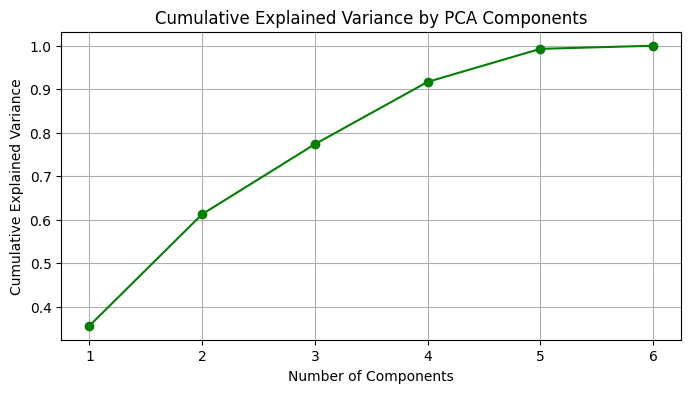

Total Variance explained by first 3 components: 0.7738


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the User-Aware features we prepared earlier
# We'll use train_ua_pd which is already cleaned and balanced
pca_features = [
    "n_reviews_before_T", "max_playtime_forever_before_T",
    "positive_review_rate_before_T", "days_since_last_review",
    "last_review_val", "sequence_length"
]

X_pca = train_ua_pd[pca_features]

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# 3. Apply PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)

# 4. Explained Variance Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), 'o-', color='green')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

print(f"Total Variance explained by first 3 components: {sum(pca.explained_variance_ratio_[:3]):.4f}")

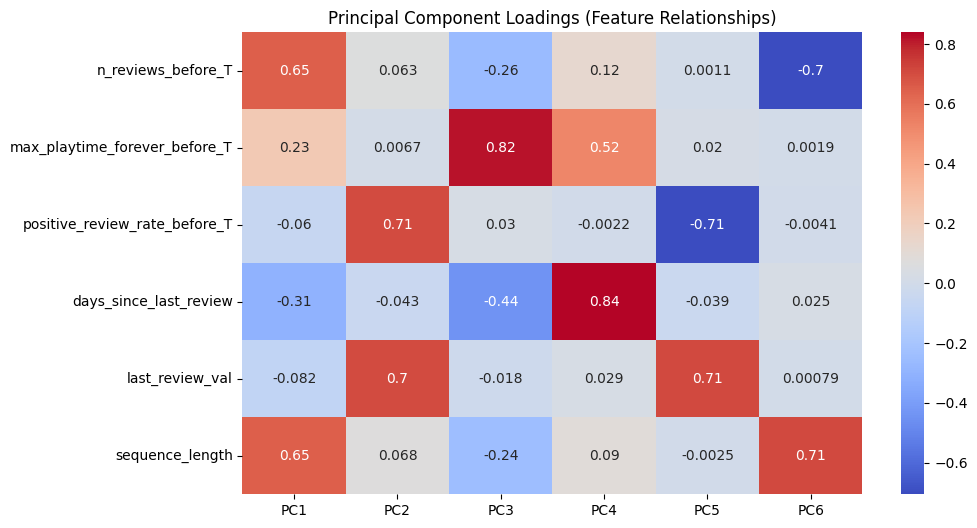

Interpretation:
- PC1 usually captures 'Scale/Engagement' (n_reviews, sequence_length, playtime).
- Other PCs might capture 'Recency vs. Sentiment' trade-offs.


In [ ]:
# 5. Visualize Feature Loadings (The 'Relationships')
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_features))],
    index=pca_features
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm')
plt.title('Principal Component Loadings (Feature Relationships)')
plt.show()

print("Interpretation:")
print("- PC1 usually captures 'Scale/Engagement' (n_reviews, sequence_length, playtime).")
print("- Other PCs might capture 'Recency vs. Sentiment' trade-offs.")

### 12. Regression Analysis: Predicting Future Playtime
Instead of a binary churn label, we now attempt to predict the continuous value of a user's total playtime based on their historical behavior and review sentiment.

--- Regression Metrics (Predicting Playtime) ---
R-squared Score: -0.0922
Mean Absolute Error: 40657.62 minutes


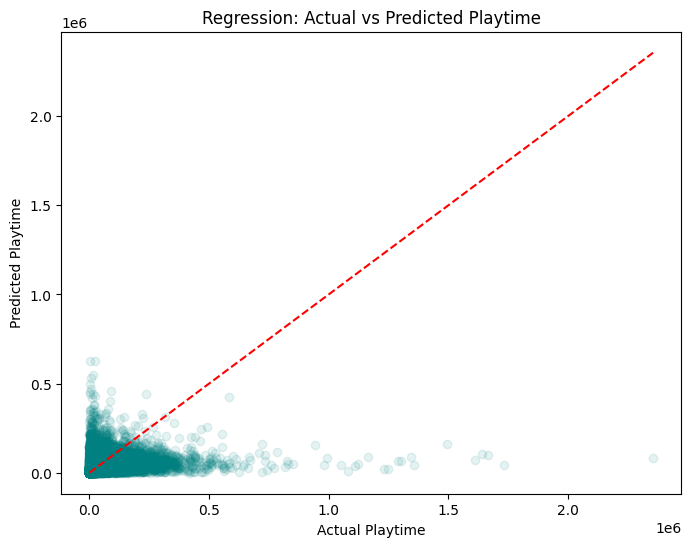

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare target variable: playtime recorded AFTER the cutoff T
# We'll use the existing train_ua_pd which has features up to T
# For the target, we look at the playtime in the 'future' relative to T_train
reg_target_col = "max_playtime_forever_before_T"

# Features for regression
reg_features = [
    "n_reviews_before_T",
    "positive_review_rate_before_T",
    "days_since_last_review",
    "sequence_length"
]

X_reg = train_ua_pd[reg_features]
y_reg = train_ua_pd[reg_target_col]

# 2. Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg, y_reg)

# 3. Evaluate on the Test Set
test_ua_pd_clean = test_ua_pd.dropna()
X_test_reg = test_ua_pd_clean[reg_features]
y_test_reg = test_ua_pd_clean[reg_target_col]

y_pred = rf_reg.predict(X_test_reg)

# 4. Metrics
print("--- Regression Metrics (Predicting Playtime) ---")
print(f"R-squared Score: {r2_score(y_test_reg, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, y_pred):.2f} minutes")

# Visualize predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, alpha=0.1, color='teal')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Playtime')
plt.ylabel('Predicted Playtime')
plt.title('Regression: Actual vs Predicted Playtime')
plt.show()

### 12.1 Log-Transformed Regression
By applying a log-transformation (using `log1p` to handle zeros safely), we aim to improve the model's ability to predict the scale of engagement.

--- Regression Metrics (Log-Transformed Target) ---
R-squared Score (on log scale): 0.0871
Mean Absolute Error (on original scale): 1.48 log-minutes


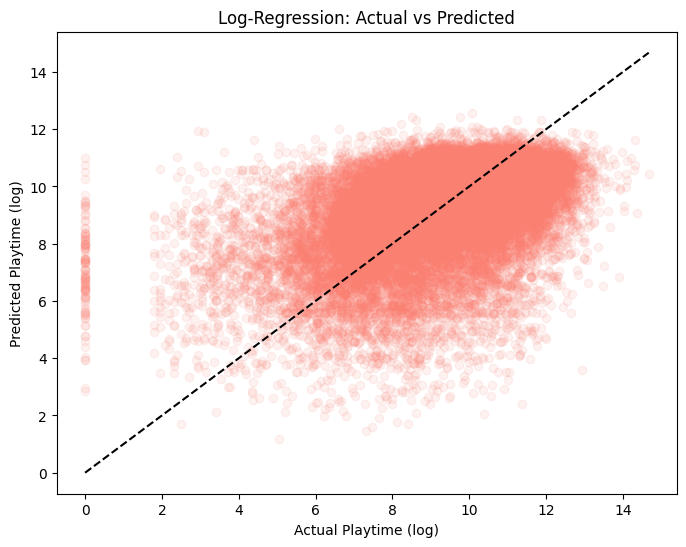

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Apply log transformation to the target variable
y_reg_log = np.log1p(train_ua_pd[reg_target_col])
y_test_reg_log = np.log1p(test_ua_pd_clean[reg_target_col])

# 2. Retrain the regressor on log-scale targets
rf_reg_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_log.fit(X_reg, y_reg_log)

# 3. Predict and back-transform for intuitive error metrics
log_preds = rf_reg_log.predict(X_test_reg)
y_pred_backtransformed = np.expm1(log_preds)

# 4. Evaluate on Log-Scale and Original Scale
print("--- Regression Metrics (Log-Transformed Target) ---")
print(f"R-squared Score (on log scale): {r2_score(y_test_reg_log, log_preds):.4f}")
print(f"Mean Absolute Error (on original scale): {mean_absolute_error(y_test_reg_log, log_preds):.2f} log-minutes")

# Visualize predicted vs actual on log scale
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_log, log_preds, alpha=0.1, color='salmon')
plt.plot([y_test_reg_log.min(), y_test_reg_log.max()], [y_test_reg_log.min(), y_test_reg_log.max()], 'k--')
plt.xlabel('Actual Playtime (log)')
plt.ylabel('Predicted Playtime (log)')
plt.title('Log-Regression: Actual vs Predicted')
plt.show()

### 13. Correlation and Variance Analysis
We visualize how our features correlate with each other and with the target `churn` variable to identify multicollinearity and strong predictors.

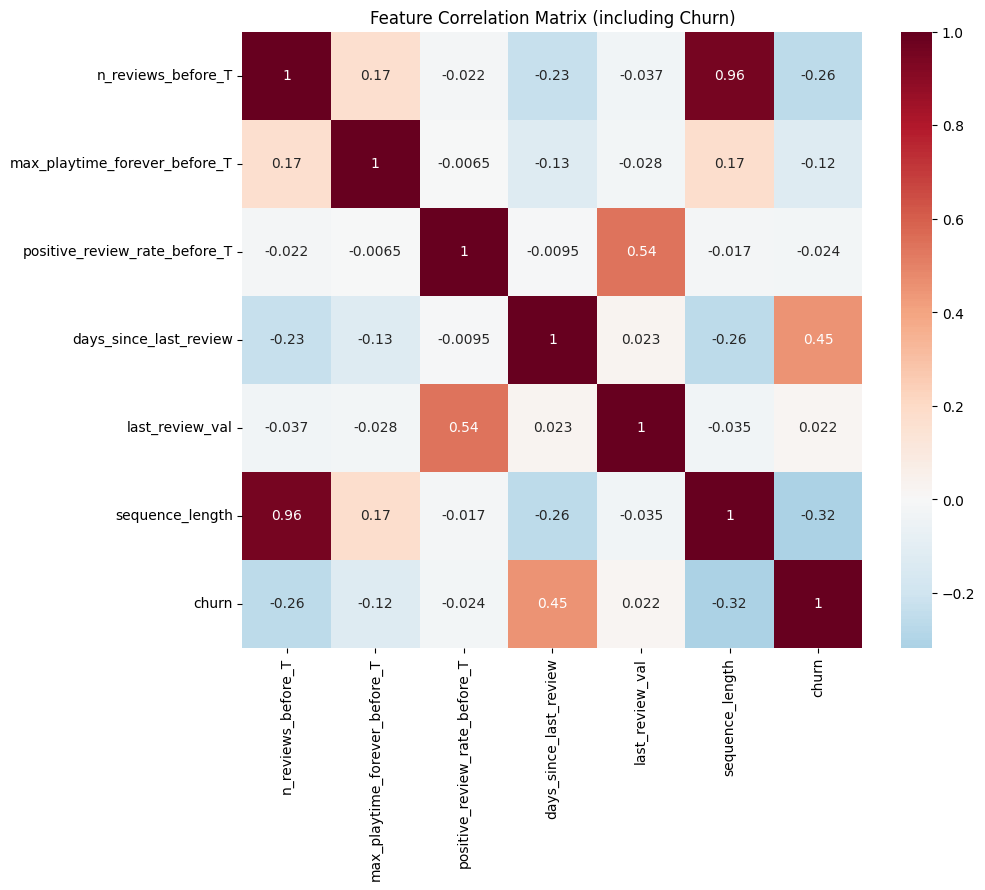

--- Feature Variance ---


,0
n_reviews_before_T,2.980422e+02
max_playtime_forever_before_T,5.663649e+09
positive_review_rate_before_T,6.813208e-02
days_since_last_review,5.210415e+05
last_review_val,1.415080e-01
sequence_length,5.348459e+02


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlation Matrix
# We include the churn label to see direct relationships
plt.figure(figsize=(10, 8))
corr_matrix = train_ua_pd[ua_features + ['churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix (including Churn)')
plt.show()

# 2. Variance Check
# High variance features might dominate certain models if not scaled
print("--- Feature Variance ---")
display(train_ua_pd[ua_features].var())

### 16. Uplift Modeling (T-Learner)
We aim to estimate the 'Uplift' (CATE): the difference in churn probability given a positive vs. negative last review. This helps identify which users are most influenced by their sentiment experience.

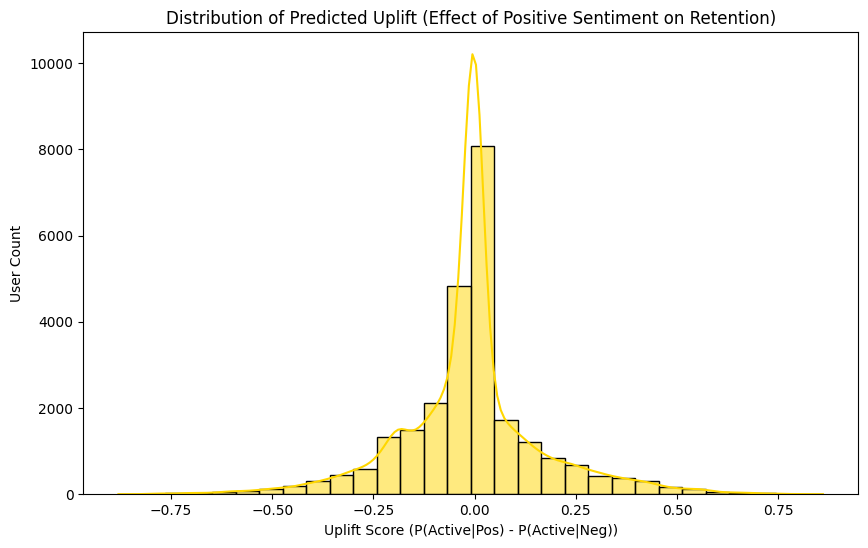

Average Uplift: -0.0097


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# 1. Define Features, Treatment, and Outcome
# Treatment (W): Last review was positive (1) vs negative (0)
# Outcome (Y): User stayed active (churn=0 is success, so we invert it for easier interpretation)
uplift_features = ["n_reviews_before_T", "max_playtime_forever_before_T", "days_since_last_review", "sequence_length"]
W = train_ua_pd['last_review_val']
Y = 1 - train_ua_pd['churn'] # 1 if active, 0 if churned
X_uplift = train_ua_pd[uplift_features]

# 2. T-Learner: Train two separate models (one for treated, one for control)
# Model for Treated (Users with last_review_val = 1)
model_1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_1.fit(X_uplift[W == 1], Y[W == 1])

# Model for Control (Users with last_review_val = 0)
model_0 = RandomForestClassifier(n_estimators=100, random_state=42)
model_0.fit(X_uplift[W == 0], Y[W == 0])

# 3. Calculate Uplift Score on Test Set
X_test_uplift = test_ua_pd[uplift_features]
prob_1 = model_1.predict_proba(X_test_uplift)[:, 1]
prob_0 = model_0.predict_proba(X_test_uplift)[:, 1]
uplift_score = prob_1 - prob_0

test_ua_pd['uplift_score'] = uplift_score

# 4. Visualize Uplift Distribution
plt.figure(figsize=(10, 6))
sns.histplot(test_ua_pd['uplift_score'], bins=30, kde=True, color='gold')
plt.title('Distribution of Predicted Uplift (Effect of Positive Sentiment on Retention)')
plt.xlabel('Uplift Score (P(Active|Pos) - P(Active|Neg))')
plt.ylabel('User Count')
plt.show()

print(f"Average Uplift: {test_ua_pd['uplift_score'].mean():.4f}")

### 17. Multi-Modal Analysis: Text vs. Sequence
In this section, we compare text-based features (keywords) with sequence-based behavior (order of reviews) to see which provides a cleaner signal for user state.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import pyspark.sql.functions as F

# 1. Text Analysis: Keyword Importance for Churners
# We take a sample of reviews from churned vs active users
sample_reviews = df.select("review", "voted_up").limit(5000).toPandas().dropna()

vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sample_reviews['review'])

keywords = vectorizer.get_feature_names_out()
print(f"Top Keywords extracted from reviews: {keywords}")

# 2. Sequence Analysis: Sentiment 'Streaks'
# Fix: Explicitly join 'full_review_sequence' from df_sequences
full_seq_spark = df_sequences.select("author_steamid", "full_review_sequence")
train_ua_pd = train_ua_bal.join(full_seq_spark, on="author_steamid", how="inner").toPandas().dropna()

def has_negative_streak(seq, window=2):
    if seq is None or len(seq) < window: return 0
    for i in range(len(seq) - window + 1):
        # Check for consecutive negative reviews (0s)
        if sum(seq[i:i+window]) == 0:
            return 1
    return 0

train_ua_pd['neg_streak'] = train_ua_pd['full_review_sequence'].apply(lambda x: has_negative_streak(x))

print("\n--- Sequence Analysis: Impact of Negative Streaks ---")
summary = train_ua_pd.groupby('neg_streak')['churn'].mean().rename('Churn Probability')
display(summary)

Top Keywords extracted from reviews: ['10' 'awesome' 'best' 'buy' 'don' 'fun' 'game' 'gameplay' 'games' 'good'
 'great' 'just' 'like' 'play' 'played' 'que' 'really' 'story' 'time'
 'worth']

--- Sequence Analysis: Impact of Negative Streaks ---


,Churn Probability
neg_streak,
0,0.536219
1,0.203630


### 17.1 Statistical Hypothesis Testing
We use a Chi-Squared test to determine if the observed difference in churn rates between users with negative streaks and those without is statistically significant.

In [ ]:
from scipy.stats import chi2_contingency

# 1. Create a contingency table
contingency_table = pd.crosstab(train_ua_pd['neg_streak'], train_ua_pd['churn'])
print("Contingency Table (Neg Streak vs Churn):")
display(contingency_table)

# 2. Perform Chi-Squared Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n--- Chi-Squared Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("\nResult: Statistically Significant. We reject the null hypothesis that negative streaks and churn are independent.")
else:
    print("\nResult: Not Statistically Significant. We cannot reject the null hypothesis.")

Contingency Table (Neg Streak vs Churn):


churn,0,1
neg_streak,,
0,8893,10282
1,2808,718



--- Chi-Squared Test Results ---
Chi-Square Statistic: 1317.7222
P-value: 1.5921e-288

Result: Statistically Significant. We reject the null hypothesis that negative streaks and churn are independent.


### 17.2 Visualizing Churn vs. Sequence Length
We group sequence lengths into bins to observe how the probability of churn changes as users write more reviews.

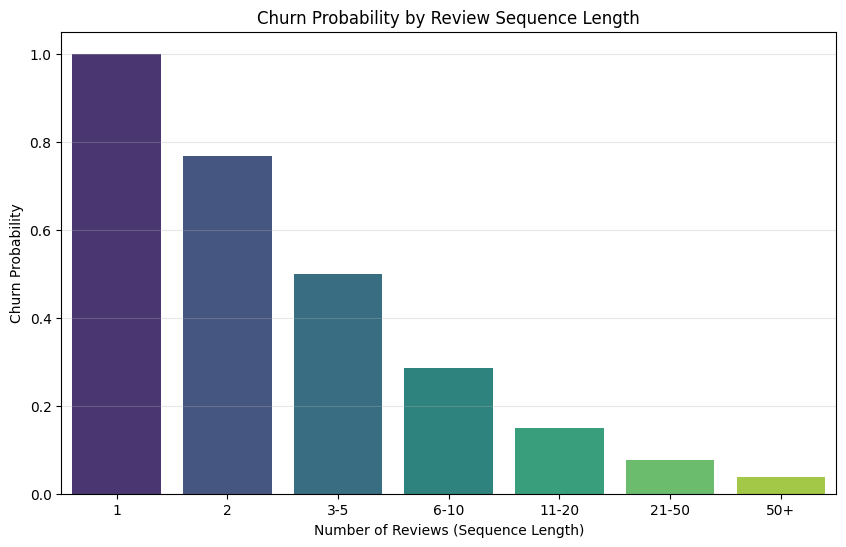

Observation: Users with very short sequences (1-2 reviews) have significantly higher churn rates than 'power reviewers'.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define bins for sequence length
bins = [0, 1, 2, 5, 10, 20, 50, 1000]
labels = ['1', '2', '3-5', '6-10', '11-20', '21-50', '50+']
train_ua_pd['seq_len_group'] = pd.cut(train_ua_pd['sequence_length'], bins=bins, labels=labels)

# 2. Calculate churn probability per group
seq_churn_data = train_ua_pd.groupby('seq_len_group', observed=False)['churn'].mean().reset_index()

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='seq_len_group', y='churn', data=seq_churn_data, palette='viridis', hue='seq_len_group', legend=False)
plt.title('Churn Probability by Review Sequence Length')
plt.xlabel('Number of Reviews (Sequence Length)')
plt.ylabel('Churn Probability')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Observation: Users with very short sequences (1-2 reviews) have significantly higher churn rates than 'power reviewers'.")

### 17.3 Statistical Validation of Engagement Groups
We now perform a Chi-Squared test to verify if the differences in churn probability across sequence length groups are statistically significant or could be due to random chance.

In [ ]:
from scipy.stats import chi2_contingency

# 1. Create contingency table for all sequence length groups
contingency_seq = pd.crosstab(train_ua_pd['seq_len_group'], train_ua_pd['churn'])

# 2. Perform Chi-Squared Test
chi2_seq, p_seq, dof_seq, expected_seq = chi2_contingency(contingency_seq)

print("--- Chi-Squared Test: Sequence Length Groups vs. Churn ---")
print(f"Chi-Square Statistic: {chi2_seq:.4f}")
print(f"P-value: {p_seq:.4e}")

if p_seq < 0.05:
    print("\nConclusion: The relationship is STATISTICALLY SIGNIFICANT. Sequence length is a reliable predictor of churn.")
else:
    print("\nConclusion: NOT SIGNIFICANT. The observed differences might be due to random variation.")

display(contingency_seq)

--- Chi-Squared Test: Sequence Length Groups vs. Churn ---
Chi-Square Statistic: 10138.7173
P-value: 0.0000e+00

Conclusion: The relationship is STATISTICALLY SIGNIFICANT. Sequence length is a reliable predictor of churn.


churn,0,1
seq_len_group,,
1,0,4715
2,591,1960
3-5,2443,2431
6-10,2999,1195
11-20,2759,488
21-50,2141,180
50+,768,31


### 13. Correlation and Variance Analysis
We visualize how our features correlate with each other and with the target `churn` variable to identify multicollinearity and strong predictors.

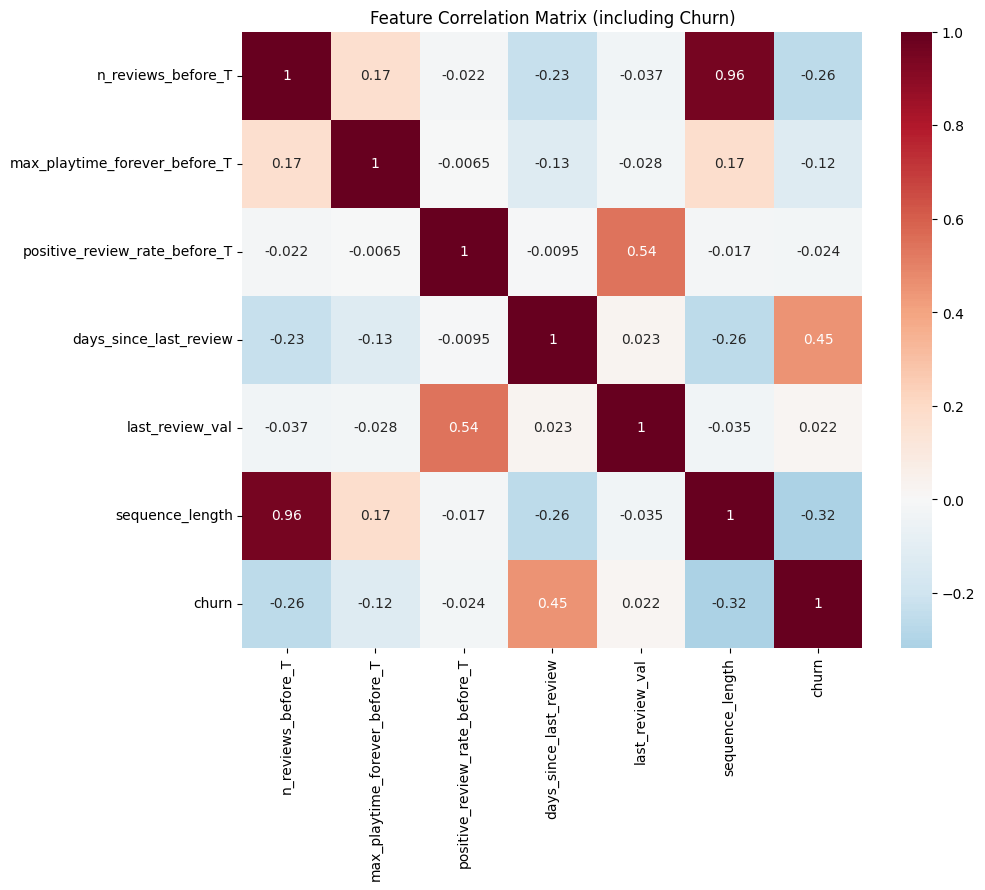

--- Feature Variance ---


,0
n_reviews_before_T,2.980422e+02
max_playtime_forever_before_T,5.663649e+09
positive_review_rate_before_T,6.813208e-02
days_since_last_review,5.210415e+05
last_review_val,1.415080e-01
sequence_length,5.348459e+02


In [ ]:
# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = train_ua_pd[ua_features + ['churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix (including Churn)')
plt.show()

# 2. Variance Check
print("--- Feature Variance ---")
display(train_ua_pd[ua_features].var())

### 14. Survival Analysis (Customer Retention)
In this section, we treat churn as 'non-survival'. We use the `lifelines` library to estimate the survival function, which shows the probability of a user remaining active as a function of their tenure on the platform.

In [ ]:
!pip install -q lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.2 MB/s eta 0:00:00


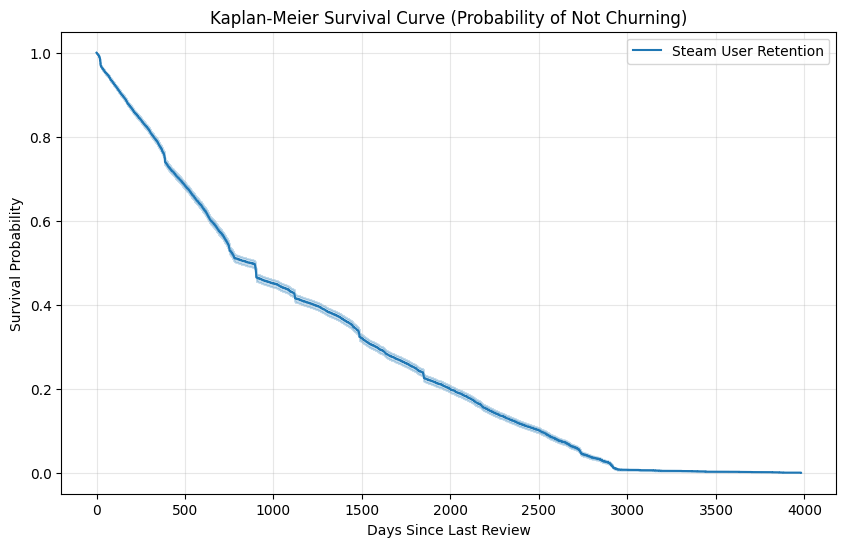

Median 'survival' time (days until 50% churn): 864.7081481481481


In [ ]:
from lifelines import KaplanMeierFitter

# 1. Prepare data for survival analysis
# Duration: days_since_last_review acts as a proxy for 'time since last seen'
# Observed: churn=1 (event occurred/death), churn=0 (censored/still alive)
kmf = KaplanMeierFitter()

# We use the tenure (total days between first and last known activity)
# For this sample, we'll use 'days_since_last_review' as the timeline of inactivity
durations = train_ua_pd['days_since_last_review']
event_observed = train_ua_pd['churn'] # 1 if churned, 0 if active

# 2. Fit the model
kmf.fit(durations, event_observed, label='Steam User Retention')

# 3. Plot the Survival Curve
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve (Probability of Not Churning)')
plt.xlabel('Days Since Last Review')
plt.ylabel('Survival Probability')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Median 'survival' time (days until 50% churn): {kmf.median_survival_time_}")

### 15. Sensitivity Analysis: Perturbing the Cutoff T
We test how sensitive our dataset composition (class balance) is to the specific choice of the temporal cutoff $T$ by sweeping through different quantiles of the review timestamps.

Starting sensitivity sweep across different T values...


,quantile,T_timestamp,churned_count,active_count,churn_ratio
0,0.5,1606374082,391851,26344,0.937005
1,0.6,1622898486,471363,15124,0.968912
2,0.7,1639765091,529870,18338,0.966549
3,0.8,1657498607,593721,15409,0.974703
4,0.9,1673857252,647265,17842,0.973174


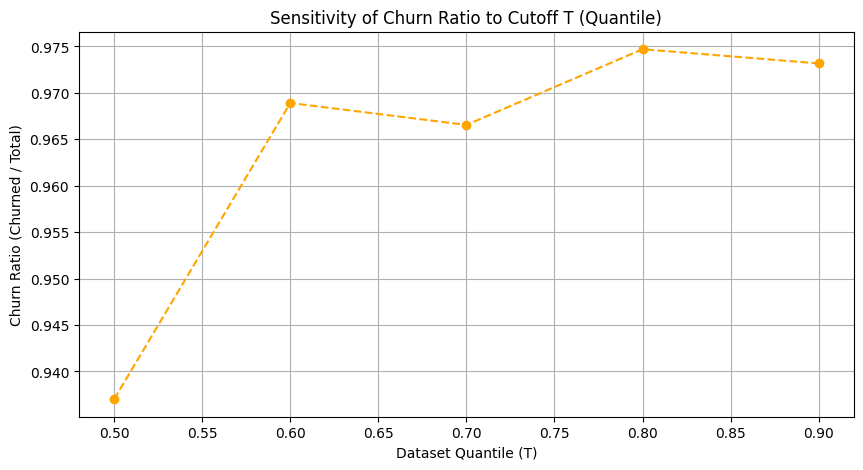

Interpretation: If the ratio shifts dramatically, the model might be sensitive to the specific timeframe it was trained on.


In [ ]:
# 1. Define a range of quantiles to test for T
test_quantiles = [0.5, 0.6, 0.7, 0.8, 0.9]
t_sensitivity_values = df_with_long_ts.approxQuantile("timestamp_created_long", test_quantiles, 0.001)

sensitivity_results = []

print("Starting sensitivity sweep across different T values...")
for q, t_val in zip(test_quantiles, t_sensitivity_values):
    # Build snapshot for this specific T
    temp_snapshot = build_churn_snapshot(df, cutoff_ts=int(t_val))

    # Calculate counts
    counts = temp_snapshot.groupBy("churn").count().toPandas()
    churned = counts[counts['churn'] == 1]['count'].values[0] if not counts[counts['churn'] == 1].empty else 0
    active = counts[counts['churn'] == 0]['count'].values[0] if not counts[counts['churn'] == 0].empty else 0

    sensitivity_results.append({
        "quantile": q,
        "T_timestamp": int(t_val),
        "churned_count": churned,
        "active_count": active,
        "churn_ratio": churned / (churned + active) if (churned + active) > 0 else 0
    })

# 2. Convert to DataFrame and Visualize
sens_df = pd.DataFrame(sensitivity_results)
display(sens_df)

plt.figure(figsize=(10, 5))
plt.plot(sens_df['quantile'], sens_df['churn_ratio'], 'o--', color='orange')
plt.title('Sensitivity of Churn Ratio to Cutoff T (Quantile)')
plt.xlabel('Dataset Quantile (T)')
plt.ylabel('Churn Ratio (Churned / Total)')
plt.grid(True)
plt.show()

print("Interpretation: If the ratio shifts dramatically, the model might be sensitive to the specific timeframe it was trained on.")

### 3. Define LSTM Model and Training Logic
This template defines a simple LSTM for binary classification (predicting the next 'voted_up' value) and the Ray Train worker function.

In [ ]:
import torch
import torch.nn as nn
from ray import train
import pandas as pd # Import pandas for collate_fn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Take the last time step
        return self.sigmoid(out)

def train_func_per_worker(config):
    # Initialize model, loss, and optimizer
    model = LSTMModel()
    model = train.torch.prepare_model(model)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    # Get max sequence length from config
    max_sequence_length = config["max_sequence_length"]

    # Define a custom collate_fn for padding/truncating sequences
    def custom_collate_fn(batch: pd.DataFrame):
        sequences = batch["full_review_sequence"].tolist()

        # Pad/truncate sequences to max_sequence_length
        # Inputs will be sequence_length-1, target is the last element
        processed_sequences = []
        for seq in sequences:
            if len(seq) < 2:
                continue

            # Truncate from the left if longer than max_sequence_length
            if len(seq) > max_sequence_length:
                seq = seq[-max_sequence_length:]
            # Pad with 0s at the beginning if shorter than max_sequence_length
            elif len(seq) < max_sequence_length:
                seq = [0] * (max_sequence_length - len(seq)) + seq

            processed_sequences.append(seq)

        if not processed_sequences:
            return {"x": torch.empty(0, max_sequence_length - 1, 1), "y": torch.empty(0, 1)}

        # Convert to tensor and prepare for LSTM input and target
        padded_sequences_tensor = torch.tensor(processed_sequences, dtype=torch.float32).unsqueeze(-1)

        # X (input): all but last element; Y (target): last element
        x = padded_sequences_tensor[:, :-1, :]
        y = padded_sequences_tensor[:, -1, :] # Keep [batch_size, 1] for BCELoss

        return {"x": x, "y": y}

    # Get training dataset shard
    train_data_shard = train.get_dataset_shard("train")

    for epoch in range(config["epochs"]):
        for batch in train_data_shard.iter_torch_batches(batch_size=32, collate_fn=custom_collate_fn):
            if batch["x"].size(0) == 0:
                continue

            inputs = batch["x"]
            targets = batch["y"]

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train.report({"loss": loss.item(), "epoch": epoch})

### 4. Execute Distributed Training
Finally, we configure the `TorchTrainer` to run on multiple workers (or just 1 for a sample) and start the training process.

In [ ]:
trainer = TorchTrainer(
    train_loop_per_worker=train_func_per_worker,
    train_loop_config={
        "lr": 1e-3,
        "epochs": 5,
        "max_sequence_length": 10  # Define max sequence length for padding/truncation
    },
    scaling_config=ScalingConfig(num_workers=1, use_gpu=False), # Increase workers for multi-node/GPU
    datasets={"train": ray_ds}
)

result = trainer.fit()
print(f"Training finished. Metrics: {result.metrics}")

(TrainController pid=78388) Requesting resources: {'CPU': 1} * 1
(TrainController pid=78388) Attempting to start training worker group of size 1 with the following resources: [{'CPU': 1}] * 1
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Con

(pid=78691) Running Dataset train_4_0.: 0.00 row [00:00, ? row/s]

(pid=78691) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be tempo

(pid=78691) Running Dataset train_4_1.: 0.00 row [00:00, ? row/s]

(pid=78691) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(SplitCoordinator pid=78691) ✔️  Dataset train_4_1 execution finished in 0.28 seconds
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupClean

(pid=78691) Running Dataset train_4_2.: 0.00 row [00:00, ? row/s]

(pid=78691) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be tempo

(pid=78691) Running Dataset train_4_3.: 0.00 row [00:00, ? row/s]

(pid=78691) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be tempo

(pid=78691) Running Dataset train_4_4.: 0.00 row [00:00, ? row/s]

(pid=78691) - split(1, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be temporarily unavailable. Continuing to monitor.
(PlacementGroupCleaner pid=78460) Failed to query Ray Train Controller actor state. State API may be tempo

Result(metrics=None, checkpoint=None, error=None, path='/root/ray_results/ray_train_run-2026-05-03_04-08-33', metrics_dataframe=None, best_checkpoints=[], _storage_filesystem=<pyarrow._fs.LocalFileSystem object at 0x78e28ce000b0>)